In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/BIA - Internship Projects/Datasets/NYPD_Shooting_Incident_Data__Historic_.csv')

# EDA and Preprocessing

In [ ]:
df.head()

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,STATISTICAL_MURDER_FLAG,...,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
0,228798151,05/27/2021,21:30:00,QUEENS,NaN,105,0.0,NaN,NaN,False,...,NaN,NaN,18-24,M,BLACK,1.058925e+06,180924.000000,40.662965,-73.730839,POINT (-73.73083868899994 40.662964620000025)
1,137471050,06/27/2014,17:40:00,BRONX,NaN,40,0.0,NaN,NaN,False,...,NaN,NaN,18-24,M,BLACK,1.005028e+06,234516.000000,40.810352,-73.924942,POINT (-73.92494232599995 40.81035186300006)
2,147998800,11/21/2015,03:56:00,QUEENS,NaN,108,0.0,NaN,NaN,True,...,NaN,NaN,25-44,M,WHITE,1.007668e+06,209836.531250,40.742607,-73.915492,POINT (-73.91549174199997 40.74260663300004)
3,146837977,10/09/2015,18:30:00,BRONX,NaN,44,0.0,NaN,NaN,False,...,NaN,NaN,<18,M,WHITE HISPANIC,1.006537e+06,244511.140625,40.837782,-73.919457,POINT (-73.91945661499994 40.83778200300003)
4,58921844,02/19/2009,22:58:00,BRONX,NaN,47,0.0,NaN,NaN,True,...,M,BLACK,45-64,M,BLACK,1.024922e+06,262189.406250,40.886238,-73.852910,POINT (-73.85290950899997 40.88623791800006)


These are the first 5 rows of the data.

In [ ]:
df.tail()

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,STATISTICAL_MURDER_FLAG,...,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
27307,245029823,05/14/2022,03:02:00,BRONX,OUTSIDE,48,0.0,STREET,(null),False,...,(null),(null),18-24,M,BLACK,1011526.0,247828.0,40.846864,-73.901413,POINT (-73.90141321 40.84686352)
27308,239583450,01/22/2022,13:15:00,MANHATTAN,OUTSIDE,30,0.0,STREET,(null),False,...,F,WHITE HISPANIC,25-44,M,WHITE HISPANIC,997458.0,240485.0,40.826743,-73.952273,POINT (-73.952273 40.826743)
27309,246825728,06/18/2022,03:29:00,MANHATTAN,OUTSIDE,32,0.0,STREET,(null),False,...,M,BLACK,25-44,M,BLACK,1000999.0,234464.0,40.810209,-73.939496,POINT (-73.9394955 40.81020941)
27310,246876579,06/19/2022,20:08:00,BRONX,INSIDE,46,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,False,...,M,BLACK,25-44,M,WHITE HISPANIC,1012980.0,251028.0,40.855644,-73.896141,POINT (-73.896141 40.855644)
27311,239861542,01/28/2022,18:14:00,BRONX,OUTSIDE,45,0.0,STREET,(null),False,...,M,BLACK,18-24,M,BLACK,1026549.0,244293.0,40.837102,-73.847134,POINT (-73.847134 40.837102)


These are the last 5 rows of the data.

In [ ]:
df.describe()

,INCIDENT_KEY,PRECINCT,JURISDICTION_CODE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
count,2.731200e+04,27312.000000,27310.000000,2.731200e+04,27312.000000,27302.000000,27302.000000
mean,1.208605e+08,65.635362,0.326913,1.009449e+06,208127.401608,40.737892,-73.909051
std,7.341286e+07,27.305705,0.737743,1.837783e+04,31886.377757,0.087525,0.066272
min,9.953245e+06,1.000000,0.000000,9.149281e+05,125756.718750,40.511586,-74.249303
25%,6.386088e+07,44.000000,0.000000,1.000029e+06,182834.335938,40.668481,-73.943027
50%,9.037222e+07,68.000000,0.000000,1.007731e+06,194486.570312,40.700318,-73.915221
75%,1.888102e+08,81.000000,0.000000,1.016838e+06,239518.468750,40.824067,-73.882330
max,2.611902e+08,123.000000,2.000000,1.066815e+06,271127.687500,40.910818,-73.702046


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27312 entries, 0 to 27311
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   INCIDENT_KEY             27312 non-null  int64  
 1   OCCUR_DATE               27312 non-null  object 
 2   OCCUR_TIME               27312 non-null  object 
 3   BORO                     27312 non-null  object 
 4   LOC_OF_OCCUR_DESC        1716 non-null   object 
 5   PRECINCT                 27312 non-null  int64  
 6   JURISDICTION_CODE        27310 non-null  float64
 7   LOC_CLASSFCTN_DESC       1716 non-null   object 
 8   LOCATION_DESC            12335 non-null  object 
 9   STATISTICAL_MURDER_FLAG  27312 non-null  bool   
 10  PERP_AGE_GROUP           17968 non-null  object 
 11  PERP_SEX                 18002 non-null  object 
 12  PERP_RACE                18002 non-null  object 
 13  VIC_AGE_GROUP            27312 non-null  object 
 14  VIC_SEX               

*   There are 14 Categorical and 7 Numeric features.
*   Our target variable is **"STATISTICAL_MURDER_FLAG"**.

In [ ]:
df.shape

(27312, 21)

This is the intial count of Rows(27312) and Columns(21).

In [ ]:
df.dtypes

,0
INCIDENT_KEY,int64
OCCUR_DATE,object
OCCUR_TIME,object
BORO,object
LOC_OF_OCCUR_DESC,object
PRECINCT,int64
JURISDICTION_CODE,float64
LOC_CLASSFCTN_DESC,object
LOCATION_DESC,object
STATISTICAL_MURDER_FLAG,bool


In [ ]:
df.nunique()

,0
INCIDENT_KEY,21420
OCCUR_DATE,5761
OCCUR_TIME,1421
BORO,5
LOC_OF_OCCUR_DESC,2
PRECINCT,77
JURISDICTION_CODE,3
LOC_CLASSFCTN_DESC,9
LOCATION_DESC,40
STATISTICAL_MURDER_FLAG,2


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
27307,False
27308,False
27309,False
27310,False


There are ZERO duplicate values.

In [ ]:
df.isna().sum()

,0
INCIDENT_KEY,0
OCCUR_DATE,0
OCCUR_TIME,0
BORO,0
LOC_OF_OCCUR_DESC,25596
PRECINCT,0
JURISDICTION_CODE,2
LOC_CLASSFCTN_DESC,25596
LOCATION_DESC,14977
STATISTICAL_MURDER_FLAG,0


*   As we can observe, there are multiple NULL values in the data.
*   Let's handle them.

In [ ]:
df.drop(columns=['LOC_OF_OCCUR_DESC','LOC_CLASSFCTN_DESC'],axis=1,inplace=True)

There were very high no. of NULL values in the above features ( LOC_OF_OCCUR_DESC,LOC_CLASSFCTN_DESC ), so we have dropped them.

In [ ]:
df['LOCATION_DESC'].value_counts()

,count
LOCATION_DESC,
MULTI DWELL - PUBLIC HOUS,4832
MULTI DWELL - APT BUILD,2835
(null),977
PVT HOUSE,951
GROCERY/BODEGA,694
BAR/NIGHT CLUB,628
COMMERCIAL BLDG,292
RESTAURANT/DINER,204
NONE,175


In [ ]:
#977 = (null)
null_in_location_desc=((14977+977)/27312)*100

print("--------------------------------------------------------")
print("% of Null Values in LOCATION_DESC : ",null_in_location_desc)
print("--------------------------------------------------------")

--------------------------------------------------------
% of Null Values in LOCATION_DESC :  58.41388400702988
--------------------------------------------------------


*   In the above feature, % of irrelevant information (which includes NULL values, UNKNOWN, (null)) is more than 50% .
*   So, we will drop it.

In [ ]:
df.drop(['LOCATION_DESC'],axis=1,inplace=True)

*   As we have numerous information regarding location, we will drop these features (PRECINCT, X_COORD_CD, Y_COORD_CD, Lon_Lat).
*   INCIDENT_KEY is an identifier, it won't be much helpful in prediction, so we will drop that too.

In [ ]:
df.drop(columns=['INCIDENT_KEY','PRECINCT','X_COORD_CD','Y_COORD_CD','Lon_Lat'],axis=1,inplace=True)

In [ ]:
df['JURISDICTION_CODE'].value_counts()

,count
JURISDICTION_CODE,
0.0,22809
2.0,4427
1.0,74


We will fill the null value with **mode** in the feature "JURISDICTION_CODE" to maintain the originality of the data instead of filling it with mean.

In [ ]:
df['JURISDICTION_CODE']=df['JURISDICTION_CODE'].fillna(df['JURISDICTION_CODE'].mode()[0])

In [ ]:
df['PERP_AGE_GROUP'].value_counts()

,count
PERP_AGE_GROUP,
18-24,6222
25-44,5687
UNKNOWN,3148
<18,1591
(null),640
45-64,617
65+,60
940,1
224,1


In [ ]:
age_map = {
    "<18": 17,
    "18-24": 21,
    "25-44": 35,
    "45-64": 55,
    "65+": 70
}
df["PERP_AGE"] = df["PERP_AGE_GROUP"].map(age_map)

In [ ]:
df.drop(['PERP_AGE_GROUP'],axis=1,inplace=True)

In [ ]:
df['PERP_AGE'].value_counts()

,count
PERP_AGE,
21.0,6222
35.0,5687
17.0,1591
55.0,617
70.0,60


In [ ]:
df['PERP_AGE'].isna().sum()

np.int64(13135)

<Axes: xlabel='PERP_AGE', ylabel='Count'>

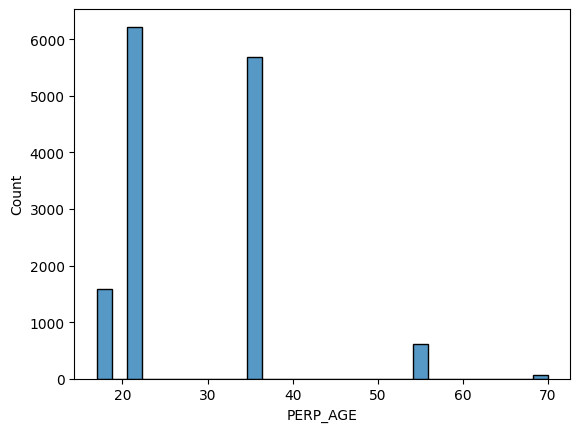

In [ ]:
sns.histplot(df['PERP_AGE'],bins=30)

The above histogram shows that most perpetrators belong to a few common age groups, with very few cases in much older ages.

In [ ]:
df["PERP_AGE"]=df["PERP_AGE"].fillna(df["PERP_AGE"].median())

In [ ]:
df['PERP_AGE'].isna().sum()

np.int64(0)

In [ ]:
df['PERP_SEX'].value_counts()

,count
PERP_SEX,
M,15439
U,1499
(null),640
F,424


In [ ]:
df['PERP_SEX']=df['PERP_SEX'].replace("(null)","U")

In [ ]:
df['PERP_SEX']=df['PERP_SEX'].fillna("U")

In [ ]:
df['PERP_SEX'].isna().sum()

np.int64(0)

In [ ]:
df['PERP_RACE'].value_counts()

,count
PERP_RACE,
BLACK,11432
WHITE HISPANIC,2341
UNKNOWN,1836
BLACK HISPANIC,1314
(null),640
WHITE,283
ASIAN / PACIFIC ISLANDER,154
AMERICAN INDIAN/ALASKAN NATIVE,2


In [ ]:
df['PERP_RACE']=df['PERP_RACE'].replace("(null)","UNKNOWN")

In [ ]:
df['PERP_RACE']=df['PERP_RACE'].fillna("UNKNOWN")

In [ ]:
df['PERP_RACE'].isna().sum()

np.int64(0)

In [ ]:
df['VIC_AGE_GROUP'].value_counts()

,count
VIC_AGE_GROUP,
25-44,12281
18-24,10086
<18,2839
45-64,1863
65+,181
UNKNOWN,61
1022,1


As the age of victims is given in a range/group, also there are special characters that are difficult to encode, so we will map this whole feature to get unique numbers .

In [ ]:
age_map = {
    "<18": 17,
    "18-24": 21,
    "25-44": 35,
    "45-64": 55,
    "65+": 70
}
df["VIC_AGE"]=df["VIC_AGE_GROUP"].map(age_map)

In [ ]:
df.drop(['VIC_AGE_GROUP'],axis=1,inplace=True)

In [ ]:
df['VIC_AGE'].value_counts()

,count
VIC_AGE,
35.0,12281
21.0,10086
17.0,2839
55.0,1863
70.0,181


In [ ]:
df['VIC_AGE'].isna().sum()

np.int64(62)

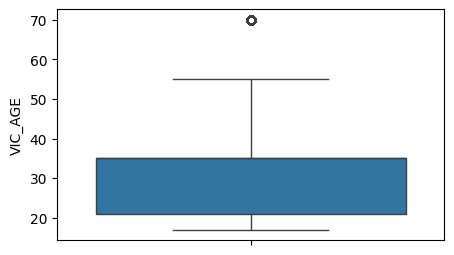

In [ ]:
plt.figure(figsize=(5,3))
sns.boxplot(df['VIC_AGE'])
plt.show()

*   There is an Outlier because of the age 70.
*   If we try to fill the NULL value using mean, it would Average all the values.
*   To overcome this we will use Median.

In [ ]:
df["VIC_AGE"]=df["VIC_AGE"].fillna(df["VIC_AGE"].median())

In [ ]:
df['VIC_AGE'].isna().sum()

np.int64(0)

In [ ]:
df['VIC_SEX'].value_counts()

,count
VIC_SEX,
M,24686
F,2615
U,11


In [ ]:
df['VIC_RACE'].value_counts()

,count
VIC_RACE,
BLACK,19439
WHITE HISPANIC,4049
BLACK HISPANIC,2646
WHITE,698
ASIAN / PACIFIC ISLANDER,404
UNKNOWN,66
AMERICAN INDIAN/ALASKAN NATIVE,10


We will not remove the rows from "VIC_SEX" & "VIC_RACE" containing UNKNOWN as their value, because the information is related to the Victim in the shooting incident.

<Axes: xlabel='Latitude', ylabel='Count'>

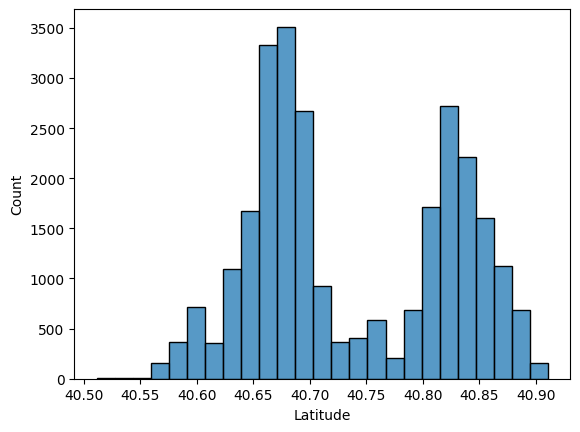

In [ ]:
sns.histplot(df['Latitude'],bins=25)

The histogram shows that the dataset's latitude values are clustered in two main geographic regions, indicating shooting incidents are concentrated in specific areas rather than evenly distributed.

In [ ]:
df["Latitude"]=df["Latitude"].fillna(df["Latitude"].median())
df["Longitude"]=df["Longitude"].fillna(df["Longitude"].median())

Missing values in Latitude and Longitude were filled using **median** to maintain the geographic consistency as our data is positively skewed and Median is more robust to outliers than Mean.

In [ ]:
df.isna().sum()

,0
OCCUR_DATE,0
OCCUR_TIME,0
BORO,0
JURISDICTION_CODE,0
STATISTICAL_MURDER_FLAG,0
PERP_SEX,0
PERP_RACE,0
VIC_SEX,0
VIC_RACE,0
Latitude,0


<Axes: >

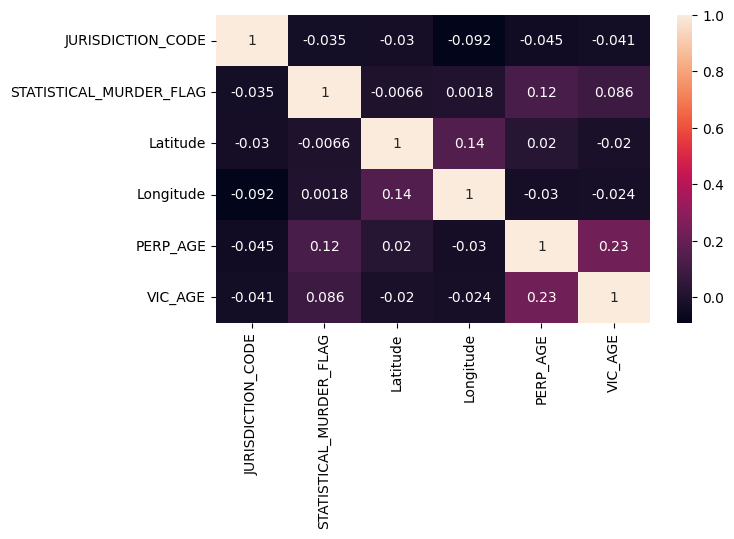

In [ ]:
cor=df.corr(numeric_only=True)
plt.figure(figsize=(7,4))
sns.heatmap(cor,annot=True)

The correlation heatmap shows that most features have weak relationships, with only a moderate negative correlation between precinct and latitude, indicating minimal linear dependency overall in the dataset.

In [ ]:
df["OCCUR_DATE"] = pd.to_datetime(df["OCCUR_DATE"])

df["OCCUR_YEAR"] = df["OCCUR_DATE"].dt.year
df["OCCUR_MONTH"] = df["OCCUR_DATE"].dt.month
df["OCCUR_DAY"] = df["OCCUR_DATE"].dt.day

As the date was in different format, we have extracted the YEAR, MONTH and DAY.

In [ ]:
df.head()  #let's check whether the changes are appearing or not.

,OCCUR_DATE,OCCUR_TIME,BORO,JURISDICTION_CODE,STATISTICAL_MURDER_FLAG,PERP_SEX,PERP_RACE,VIC_SEX,VIC_RACE,Latitude,Longitude,PERP_AGE,VIC_AGE,OCCUR_YEAR,OCCUR_MONTH,OCCUR_DAY
0,2021-05-27,21:30:00,QUEENS,0.0,False,U,UNKNOWN,M,BLACK,40.662965,-73.730839,21.0,21.0,2021,5,27
1,2014-06-27,17:40:00,BRONX,0.0,False,U,UNKNOWN,M,BLACK,40.810352,-73.924942,21.0,21.0,2014,6,27
2,2015-11-21,03:56:00,QUEENS,0.0,True,U,UNKNOWN,M,WHITE,40.742607,-73.915492,21.0,35.0,2015,11,21
3,2015-10-09,18:30:00,BRONX,0.0,False,U,UNKNOWN,M,WHITE HISPANIC,40.837782,-73.919457,21.0,17.0,2015,10,9
4,2009-02-19,22:58:00,BRONX,0.0,True,M,BLACK,M,BLACK,40.886238,-73.852910,35.0,55.0,2009,2,19


In [ ]:
df['OCCUR_TIME'].value_counts()

,count
OCCUR_TIME,
23:30:00,179
00:30:00,156
01:30:00,153
02:00:00,148
21:00:00,145
...,...
12:12:00,1
10:47:00,1
07:22:00,1


In [ ]:
df["OCCUR_HOUR"]=pd.to_datetime(df["OCCUR_TIME"]).dt.hour

/tmp/ipykernel_667/1945276092.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["OCCUR_HOUR"]=pd.to_datetime(df["OCCUR_TIME"]).dt.hour


In [ ]:
df['OCCUR_HOUR'].head()

,OCCUR_HOUR
0,21
1,17
2,3
3,18
4,22


In [ ]:
df["OCCUR_MINUTE"]=pd.to_datetime(df["OCCUR_TIME"]).dt.minute

/tmp/ipykernel_667/535817773.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["OCCUR_MINUTE"]=pd.to_datetime(df["OCCUR_TIME"]).dt.minute


In [ ]:
df['OCCUR_MINUTE']

,OCCUR_MINUTE
0,30
1,40
2,56
3,30
4,58
...,...
27307,2
27308,15
27309,29
27310,8


In [ ]:
df.drop(columns=['OCCUR_DATE','OCCUR_TIME'],axis=1,inplace=True)

In [ ]:
df.isna().sum()

,0
BORO,0
JURISDICTION_CODE,0
STATISTICAL_MURDER_FLAG,0
PERP_SEX,0
PERP_RACE,0
VIC_SEX,0
VIC_RACE,0
Latitude,0
Longitude,0
PERP_AGE,0


In [ ]:
df.dtypes

,0
BORO,object
JURISDICTION_CODE,float64
STATISTICAL_MURDER_FLAG,bool
PERP_SEX,object
PERP_RACE,object
VIC_SEX,object
VIC_RACE,object
Latitude,float64
Longitude,float64
PERP_AGE,float64


In [ ]:
'''df.to_csv("clean_shooting_incidents.csv",index=False)
from google.colab import files
files.download("clean_shooting_incidents.csv")
'''
#this will help us to download Clean & Feature engineered dataset.

'df.to_csv("clean_shooting_incidents.csv",index=False)\nfrom google.colab import files\nfiles.download("clean_shooting_incidents.csv")\n'

Now we can perform Visualizations on the Clean data.

<Axes: xlabel='STATISTICAL_MURDER_FLAG', ylabel='count'>

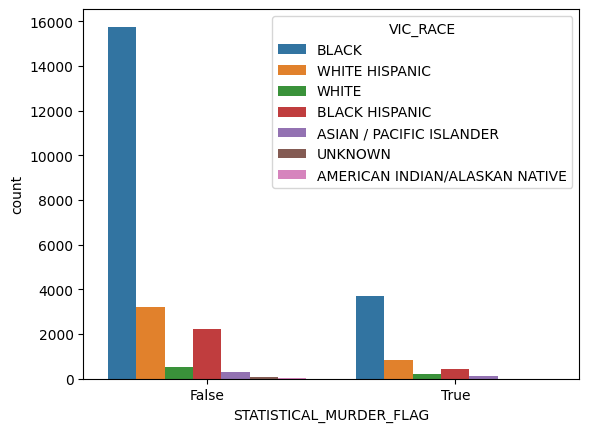

In [ ]:
sns.countplot(x=df['STATISTICAL_MURDER_FLAG'],hue=df['VIC_RACE'])

From the above representation,we can observe that the number of Shooting incidents resulted as a murder is much less than the non-murder.

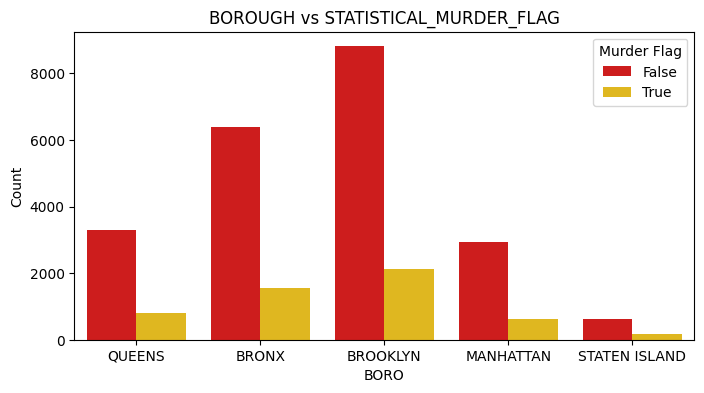

In [ ]:
plt.figure(figsize=(8,4))

sns.countplot(x=df['BORO'],hue=df['STATISTICAL_MURDER_FLAG'],palette='hot')

plt.title('BOROUGH vs STATISTICAL_MURDER_FLAG')
plt.xlabel('BORO')
plt.ylabel('Count')

plt.legend(title='Murder Flag')
plt.show()

The count plot shows how murder and non-murder incidents are distributed across boroughs, highlighting variations in crime frequency by location.

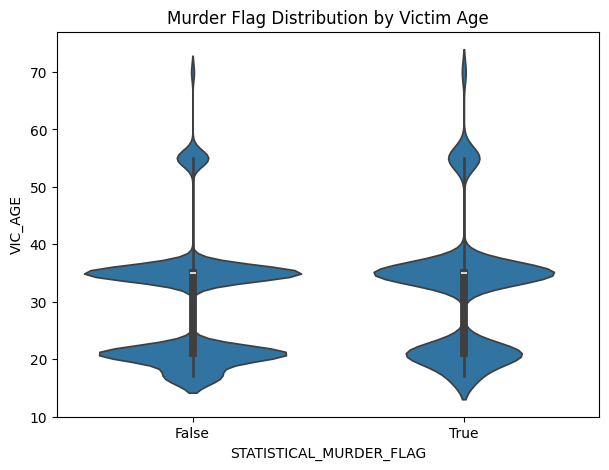

In [ ]:
plt.figure(figsize=(7,5))
sns.violinplot(x=df['STATISTICAL_MURDER_FLAG'],y=df['VIC_AGE'])
plt.title('Murder Flag Distribution by Victim Age')
plt.show()

The violin plot shows the distribution of victim ages for murder and non-murder cases, highlighting differences in age patterns and density across both groups.

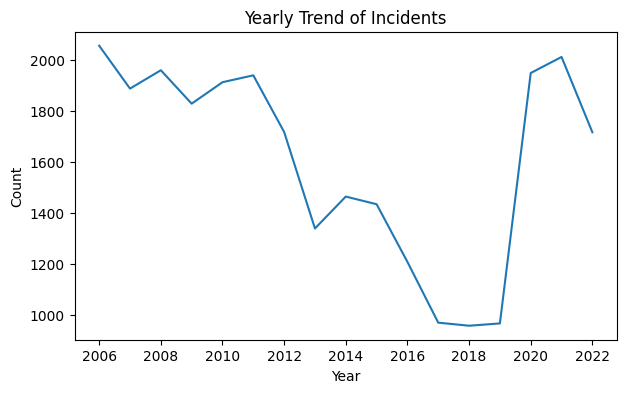

In [ ]:
trend=df.groupby(df['OCCUR_YEAR']).size()

plt.figure(figsize=(7,4))
trend.plot()
plt.title('Yearly Trend of Incidents')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

The line plot illustrates the yearly trend of incidents, showing how the number of cases changes over time and highlighting any increasing or decreasing patterns.

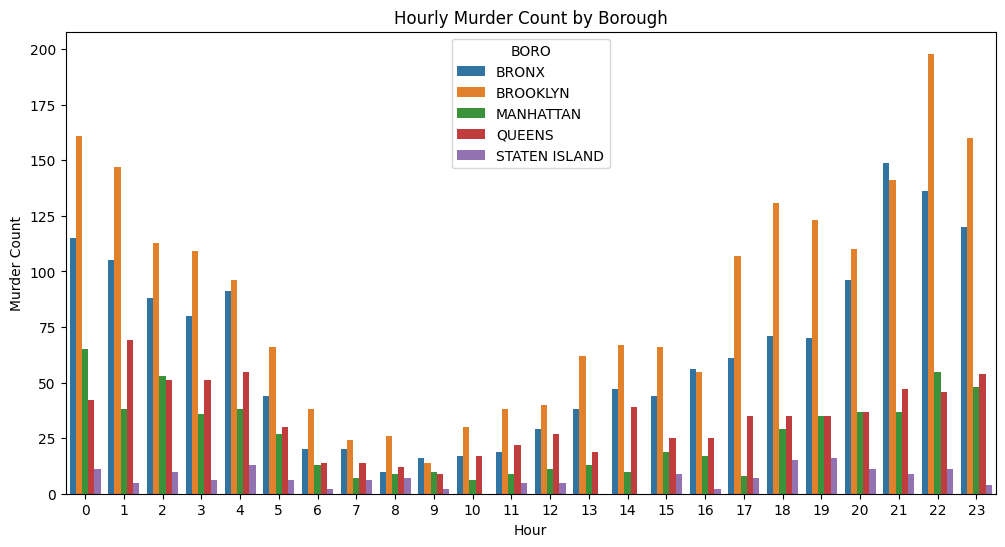

In [ ]:
plt.figure(figsize=(12,6))
data=df.groupby(['OCCUR_HOUR','BORO'])['STATISTICAL_MURDER_FLAG'].sum().reset_index()

sns.barplot(data,x='OCCUR_HOUR',y='STATISTICAL_MURDER_FLAG',hue='BORO')

plt.title('Hourly Murder Count by Borough')
plt.xlabel('Hour')
plt.ylabel('Murder Count')

plt.show()

The grouped bar chart shows how murder incidents vary by hour across different boroughs, highlighting peak times and differences between locations.

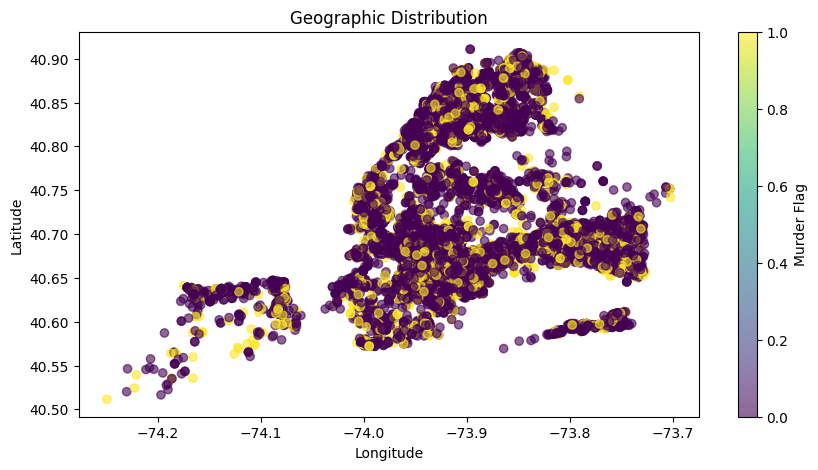

In [ ]:
plt.figure(figsize=(10,5))

plt.scatter(df['Longitude'],df['Latitude'],c=df['STATISTICAL_MURDER_FLAG'],alpha=0.6)

plt.title('Geographic Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.colorbar(label='Murder Flag')

plt.show()

Incidents are geographically clustered in specific regions, indicating hotspot areas rather than uniform distribution.

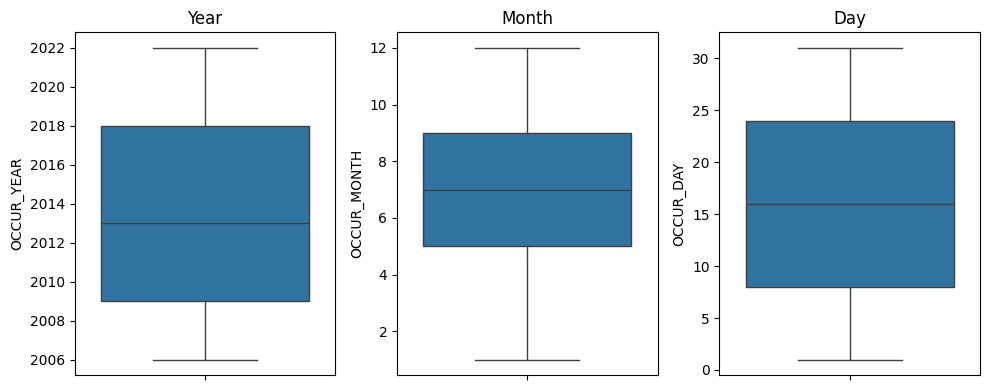

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
sns.boxplot(y=df['OCCUR_YEAR'])
plt.title('Year')

plt.subplot(1,3,2)
sns.boxplot(y=df['OCCUR_MONTH'])
plt.title('Month')

plt.subplot(1,3,3)
sns.boxplot(y=df['OCCUR_DAY'])
plt.title('Day')

plt.tight_layout()
plt.show()

The boxplots show a consistent distribution of incidents across year, month, and day, with no visible outliers indicating stable and well-bounded data.

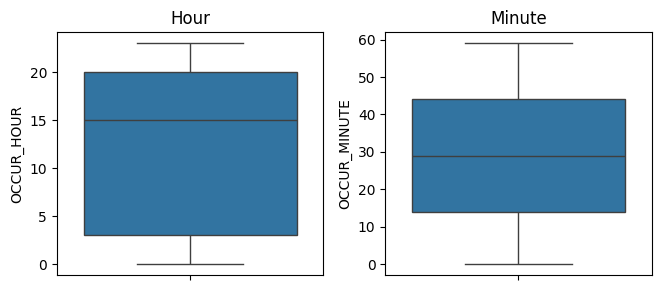

In [ ]:
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
sns.boxplot(y=df['OCCUR_HOUR'])
plt.title('Hour')

plt.subplot(1,3,2)
sns.boxplot(y=df['OCCUR_MINUTE'])
plt.title('Minute')

plt.tight_layout()
plt.show()

The boxplots indicate a uniform spread of incidents across hours and minutes, with no significant outliers, suggesting consistent temporal distribution.

In [ ]:
df['BORO'].value_counts()

,count
BORO,
BROOKLYN,10933
BRONX,7937
QUEENS,4094
MANHATTAN,3572
STATEN ISLAND,776


In [ ]:
df['PERP_RACE'].value_counts()

,count
PERP_RACE,
UNKNOWN,11786
BLACK,11432
WHITE HISPANIC,2341
BLACK HISPANIC,1314
WHITE,283
ASIAN / PACIFIC ISLANDER,154
AMERICAN INDIAN/ALASKAN NATIVE,2


In [ ]:
df['PERP_SEX'].value_counts()

,count
PERP_SEX,
M,15439
U,11449
F,424


In [ ]:
df['VIC_RACE'].value_counts()

,count
VIC_RACE,
BLACK,19439
WHITE HISPANIC,4049
BLACK HISPANIC,2646
WHITE,698
ASIAN / PACIFIC ISLANDER,404
UNKNOWN,66
AMERICAN INDIAN/ALASKAN NATIVE,10


In [ ]:
df['VIC_SEX'].value_counts()

,count
VIC_SEX,
M,24686
F,2615
U,11


As there is low cardinality in the above 5 features, we will apply One-Hot Encoding.

In [ ]:
df=pd.get_dummies(df,columns=['BORO','PERP_SEX','PERP_RACE','VIC_SEX','VIC_RACE'])

Though all the other features are numeric, we won't be applying any encoding technique.

In [ ]:
df.head()

,JURISDICTION_CODE,STATISTICAL_MURDER_FLAG,Latitude,Longitude,PERP_AGE,VIC_AGE,OCCUR_YEAR,OCCUR_MONTH,OCCUR_DAY,OCCUR_HOUR,...,VIC_SEX_F,VIC_SEX_M,VIC_SEX_U,VIC_RACE_AMERICAN INDIAN/ALASKAN NATIVE,VIC_RACE_ASIAN / PACIFIC ISLANDER,VIC_RACE_BLACK,VIC_RACE_BLACK HISPANIC,VIC_RACE_UNKNOWN,VIC_RACE_WHITE,VIC_RACE_WHITE HISPANIC
0,0.0,False,40.662965,-73.730839,21.0,21.0,2021,5,27,21,...,False,True,False,False,False,True,False,False,False,False
1,0.0,False,40.810352,-73.924942,21.0,21.0,2014,6,27,17,...,False,True,False,False,False,True,False,False,False,False
2,0.0,True,40.742607,-73.915492,21.0,35.0,2015,11,21,3,...,False,True,False,False,False,False,False,False,True,False
3,0.0,False,40.837782,-73.919457,21.0,17.0,2015,10,9,18,...,False,True,False,False,False,False,False,False,False,True
4,0.0,True,40.886238,-73.852910,35.0,55.0,2009,2,19,22,...,False,True,False,False,False,True,False,False,False,False


In [ ]:
df.shape

(27312, 36)

This is the final count of Rows(27312) and Columns(36).

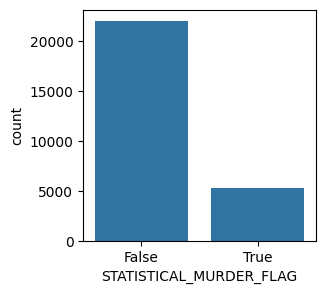

In [ ]:
plt.figure(figsize=(3,3))
sns.countplot(x=df['STATISTICAL_MURDER_FLAG'])
plt.show()

*   The data is imbalanced.
*   So, we will try modelling without balancing first.

In [ ]:
x=df.drop(["STATISTICAL_MURDER_FLAG"],axis=1)
y=df['STATISTICAL_MURDER_FLAG']

# Splitting data into X and Y

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=123,stratify=y)

# Model Selection

1. Logistic Regression was included as a simple and interpretable starting point for murder flag classification.
2. Random Forest was chosen for its ability to model non-linear patterns and it works well with imbalanced data.
3. XGBoost was applied due to its high accuracy, fast computation, and effectiveness on complex data patterns.

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lg=LogisticRegression()

lg.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred_log=lg.predict(x_test)

In [ ]:
print(classification_report(y_test,y_pred_log))

              precision    recall  f1-score   support

       False       0.81      1.00      0.89      6614
        True       0.47      0.01      0.01      1580

    accuracy                           0.81      8194
   macro avg       0.64      0.50      0.45      8194
weighted avg       0.74      0.81      0.72      8194



In [ ]:
print(confusion_matrix(y_test,y_pred_log))

[[6604   10]
 [1571    9]]


In [ ]:
accuracy_score(y_test,y_pred_log)*100

80.70539419087137

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf=RandomForestClassifier()

In [ ]:
params={
    'bootstrap':[True,False],
    'n_estimators':[100,120,150],
    'max_depth':[5,9,13,16,20],
    'min_samples_leaf':[1,2,4],
}

In [ ]:
gsc_rf=GridSearchCV(
    estimator=rf,
    param_grid=params,
    cv=2,
    scoring='f1',
    n_jobs=-1,
)

In [ ]:
gsc_rf.fit(x_train,y_train)

GridSearchCV(cv=2, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [5, 9, 13, 16, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'n_estimators': [100, 120, 150]},
             scoring='f1')

In [ ]:
gsc_rf.best_params_

{'bootstrap': False,
 'max_depth': 20,
 'min_samples_leaf': 1,
 'n_estimators': 100}

In [ ]:
y_pred_rf=gsc_rf.best_estimator_.predict(x_test)

In [ ]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

       False       0.81      0.95      0.88      6614
        True       0.22      0.05      0.09      1580

    accuracy                           0.78      8194
   macro avg       0.52      0.50      0.48      8194
weighted avg       0.70      0.78      0.72      8194



In [ ]:
print(confusion_matrix(y_test,y_pred_rf))

[[6316  298]
 [1494   86]]


In [ ]:
accuracy_score(y_test,y_pred_rf)*100

78.13033927263852

# XGBoost

In [ ]:
from xgboost.sklearn import XGBClassifier

xg=XGBClassifier()

In [ ]:
param={
    'learning_rate':[0.03,0.05,0.1],
    'max_depth': [4,5,6],
    'min_child_weight':[1,3],
    'subsample': [0.7,0.8],
    'colsample_bytree':[0.7,0.8],
    'gamma':[0,0.1],
    'n_estimators':[200,300]
}

In [ ]:
gsc_xg=GridSearchCV(
    estimator=xg,
    param_grid=param,
    scoring='f1',
    cv=2,
    n_jobs=-1,
)

In [ ]:
gsc_xg.fit(x_train,y_train)

GridSearchCV(cv=2,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8], 'gamma': [0, 0.1],
                         'learning_rate': [0.03, 0.05, 0.1],
                         'max_depth': [4, 5, 6], 'min_child_weight': [1, 3],
                         'n_estimators': [200, 300], 'subsample': [0.7, 0.8]},
             scoring='f1')

In [ ]:
gsc_xg.best_params_

{'colsample_bytree': 0.7,
 'gamma': 0,
 'learning_rate': 0.1,
 'max_depth': 6,
 'min_child_weight': 3,
 'n_estimators': 300,
 'subsample': 0.7}

In [ ]:
y_pred_xg=gsc_xg.best_estimator_.predict(x_test)

In [ ]:
print(classification_report(y_test,y_pred_xg))

              precision    recall  f1-score   support

       False       0.81      0.98      0.89      6614
        True       0.32      0.05      0.08      1580

    accuracy                           0.80      8194
   macro avg       0.57      0.51      0.49      8194
weighted avg       0.72      0.80      0.73      8194



In [ ]:
print(confusion_matrix(y_test,y_pred_xg))

[[6450  164]
 [1503   77]]


In [ ]:
accuracy_score(y_test,y_pred_xg)*100

79.65584574078594

# Oversampling

In [ ]:
from imblearn.over_sampling import SMOTE

sm=SMOTE()

In [ ]:
x_os,y_os=sm.fit_resample(x_train,y_train)

In [ ]:
x_train_os,x_test_os,y_train_os,y_test_os=train_test_split(x_os,y_os,test_size=0.3,random_state=123,stratify=y_os)

# LogReg after Oversampling

In [ ]:
lg.fit(x_train_os,y_train_os)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred_log_os=lg.predict(x_test)

In [ ]:
print(classification_report(y_test,y_pred_log_os))

              precision    recall  f1-score   support

       False       0.81      0.78      0.80      6614
        True       0.22      0.26      0.23      1580

    accuracy                           0.68      8194
   macro avg       0.52      0.52      0.52      8194
weighted avg       0.70      0.68      0.69      8194



In [ ]:
print(confusion_matrix(y_test,y_pred_log_os))

[[5150 1464]
 [1175  405]]


In [ ]:
print(accuracy_score(y_test,y_pred_log_os)*100)

67.79350744447157


# Random Forest after Oversampling

In [ ]:
gsc_rf.fit(x_train_os,y_train_os)

GridSearchCV(cv=2, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [5, 9, 13, 16, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'n_estimators': [100, 120, 150]},
             scoring='f1')

In [ ]:
gsc_rf.best_params_

{'bootstrap': False,
 'max_depth': 20,
 'min_samples_leaf': 1,
 'n_estimators': 150}

In [ ]:
y_pred_rf_os=gsc_rf.best_estimator_.predict(x_test_os)

In [ ]:
print(classification_report(y_test_os,y_pred_rf_os))

              precision    recall  f1-score   support

       False       0.79      0.96      0.87      4630
        True       0.95      0.74      0.83      4630

    accuracy                           0.85      9260
   macro avg       0.87      0.85      0.85      9260
weighted avg       0.87      0.85      0.85      9260



In [ ]:
print(confusion_matrix(y_test_os,y_pred_rf_os))

[[4443  187]
 [1197 3433]]


In [ ]:
print(accuracy_score(y_test_os,y_pred_rf_os)*100)

85.05399568034558


# XGBoost after Oversampling

In [ ]:
gsc_xg.fit(x_train_os,y_train_os)

GridSearchCV(cv=2,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8], 'gamma': [0, 0.1],
                         'learning_rate': [0.03, 0.05, 0.1],
                         'max_depth': [4, 5, 6], 'min_child_weight': [1, 3],
                         'n_estimators': [200, 300], 'subsample': [0.7, 0.8]},
             scoring='f1')

In [ ]:
gsc_xg.best_params_

{'colsample_bytree': 0.8,
 'gamma': 0.1,
 'learning_rate': 0.1,
 'max_depth': 6,
 'min_child_weight': 1,
 'n_estimators': 300,
 'subsample': 0.8}

In [ ]:
y_pred_xg_os=gsc_xg.best_estimator_.predict(x_test_os)

In [ ]:
print(classification_report(y_test_os,y_pred_xg_os))

              precision    recall  f1-score   support

       False       0.79      0.96      0.87      4630
        True       0.94      0.75      0.83      4630

    accuracy                           0.85      9260
   macro avg       0.87      0.85      0.85      9260
weighted avg       0.87      0.85      0.85      9260



In [ ]:
print(confusion_matrix(y_test_os,y_pred_xg_os))

[[4428  202]
 [1172 3458]]


In [ ]:
print(accuracy_score(y_test_os,y_pred_xg_os)*100)

85.16198704103671


# Feature Importance

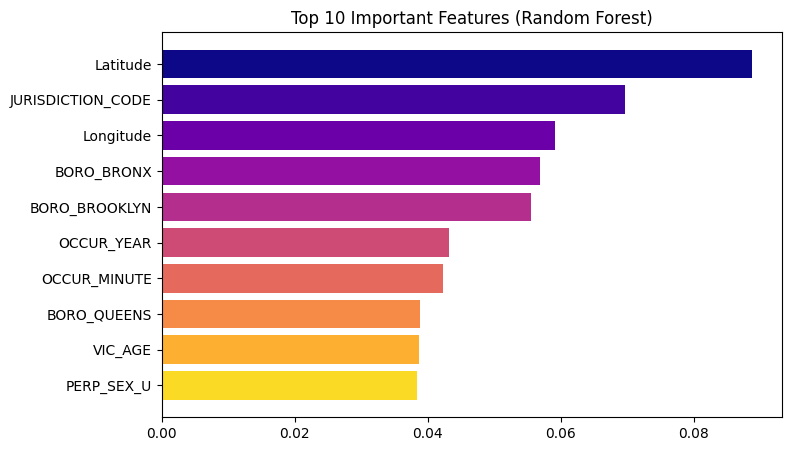

In [ ]:
rf_importance=gsc_rf.best_estimator_.feature_importances_

rf_df=pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_importance
}).sort_values(by='Importance',ascending=False)

top_n=10
rf_df_top=rf_df.head(top_n)

colors=plt.cm.plasma(np.linspace(0,3.5,len(rf_df)))

plt.figure(figsize=(8,5))
plt.barh(rf_df_top['Feature'],rf_df_top['Importance'],color=colors)
plt.gca().invert_yaxis()
plt.title('Top 10 Important Features (Random Forest)')
plt.show()

*   The model is primarily driven by location-based features, with Latitude and Longitude having the highest importance, indicating that geographical patterns strongly influence predictions.
*   Administrative and regional variables like JURISDICTION_CODE and borough features also contribute significantly.
*   Temporal (OCCUR_YEAR, OCCUR_MINUTE) and demographic (VIC_AGE, PERP_SEX) features have comparatively lower but still meaningful impact.





# Conclusion

1. In this project we applied Logistic Regression, Random Forest, and XGBoost to a classification problem. Initially, all models showed good accuracy (~78-81%) but performed poorly on the minority class due to data imbalance.

2. After applying SMOTE, the models showed significant improvement in class balance :

*   Logistic Regression improved recall but with reduced accuracy (~ 68%).
*   Random Forest and XGBoost achieved the best performance (~ 85% accuracy) with a better balance of precision and recall.

3. Overall, SMOTE effectively handled class imbalance, and Random Forest & XGBoost emerged as the most reliable models. This highlights the importance of using proper evaluation metrics beyond accuracy for classification tasks.